In [14]:
%matplotlib inline
import numpy, scipy, matplotlib.pyplot as plt, IPython.display as ipd
import librosa, librosa.display
from mirdotcom import mirdotcom; mirdotcom.init()

# Zero Crossing Rate

The [zero crossing rate](https://en.wikipedia.org/wiki/Zero-crossing_rate) indicates the number of times that a signal crosses the horizontal axis.

Let's load a signal:

In [15]:
filename = mirdotcom.get_audio("simple_loop.wav")
x, sr = librosa.load(filename)

Listen to the signal:

In [16]:
ipd.Audio(x, rate=sr)

Plot the signal:

Text(117.47222222222221, 0.5, 'Amplitude')

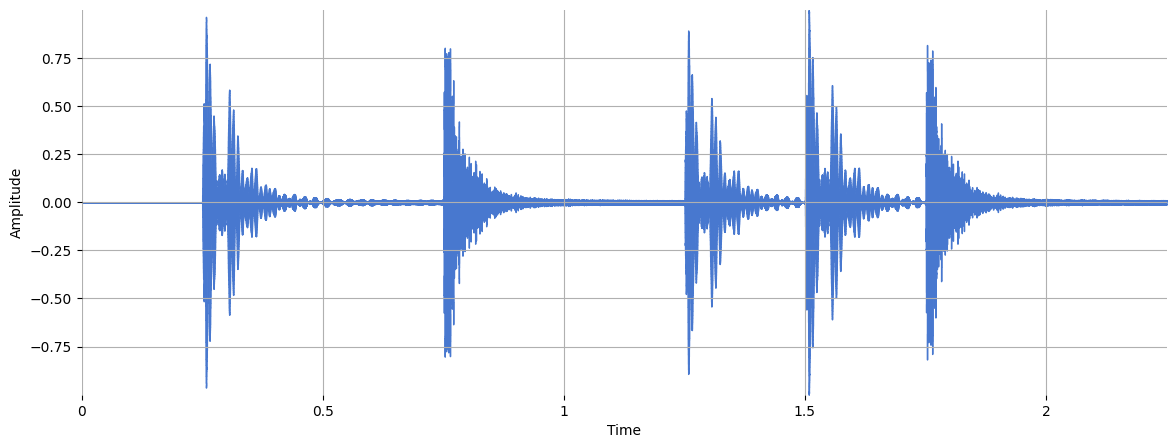

In [17]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(x, sr=sr)
plt.ylabel("Amplitude")

Let's zoom in:

Text(0, 0.5, 'Amplitude')

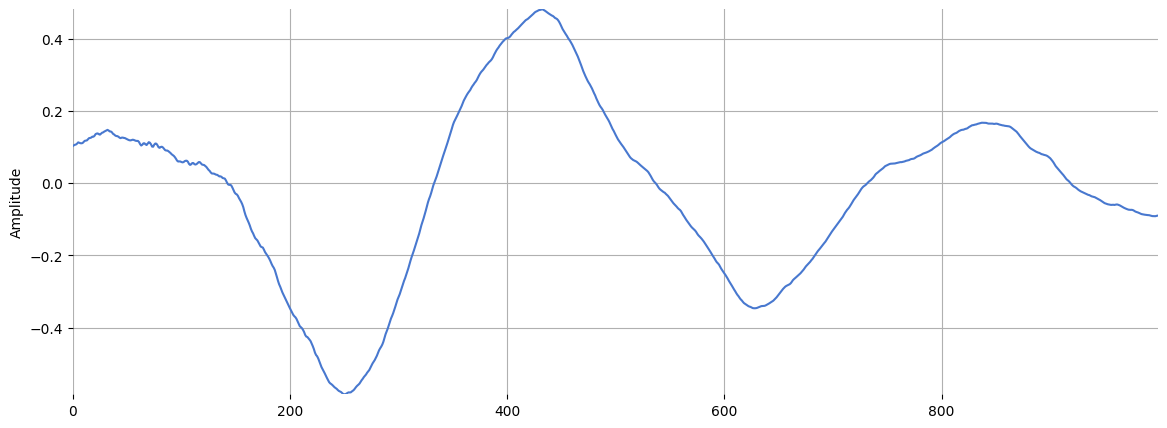

In [18]:
n0 = 6500
n1 = 7500
plt.figure(figsize=(14, 5))
plt.plot(x[n0:n1])
plt.ylabel("Amplitude")

I count five zero crossings. Let's compute the zero crossings using librosa.

In [19]:
zero_crossings = librosa.zero_crossings(x[n0:n1], pad=False)

In [20]:
zero_crossings.shape

(1000,)

That computed a binary mask where `True` indicates the presence of a zero crossing. To find the total number of zero crossings, use `sum`:

In [21]:
print(sum(zero_crossings))

5


To find the *zero-crossing rate* over time, use `zero_crossing_rate`:

In [22]:
zcrs = librosa.feature.zero_crossing_rate(x)
print(zcrs.shape)

(1, 97)


Plot the zero-crossing rate:

Text(0, 0.5, 'Zero crossing rate')

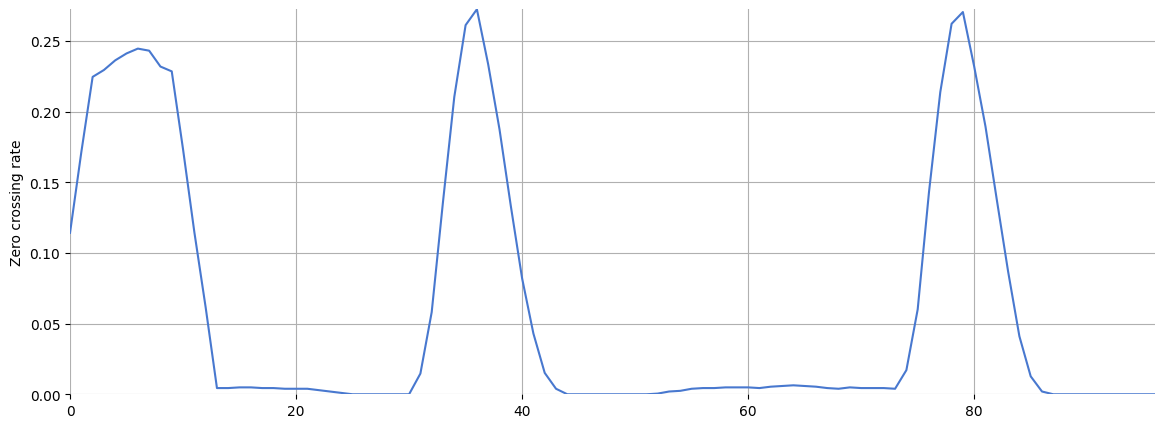

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(zcrs[0])
plt.ylabel("Zero crossing rate")

Note how the high zero-crossing rate corresponds to the presence of the snare drum.

The reason for the high rate near the beginning is because the silence oscillates quietly around zero:

Text(0, 0.5, 'Amplitude')

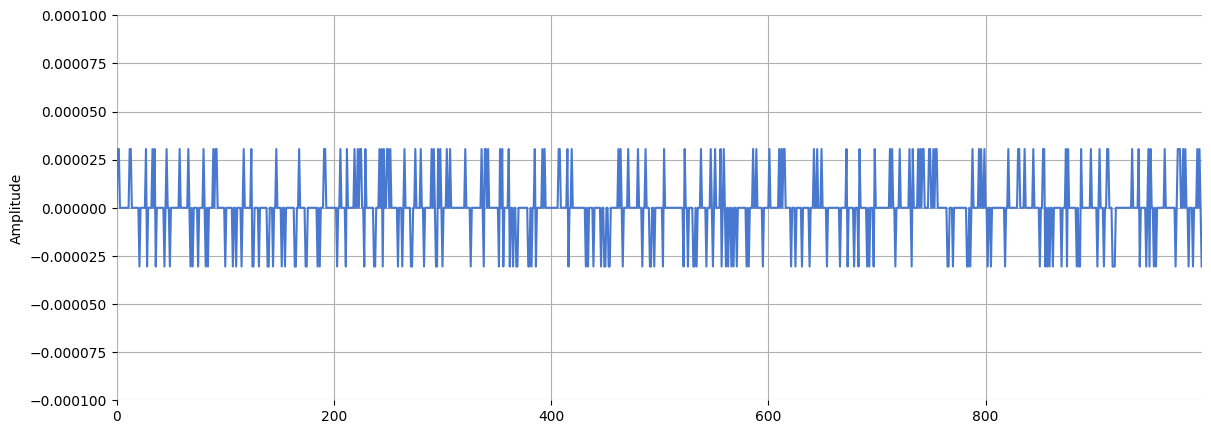

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(x[:1000])
plt.ylim(-0.0001, 0.0001)
plt.ylabel("Amplitude")

A simple hack around this is to add a small constant before computing the zero crossing rate:

Text(0, 0.5, 'Zero crossing rate')

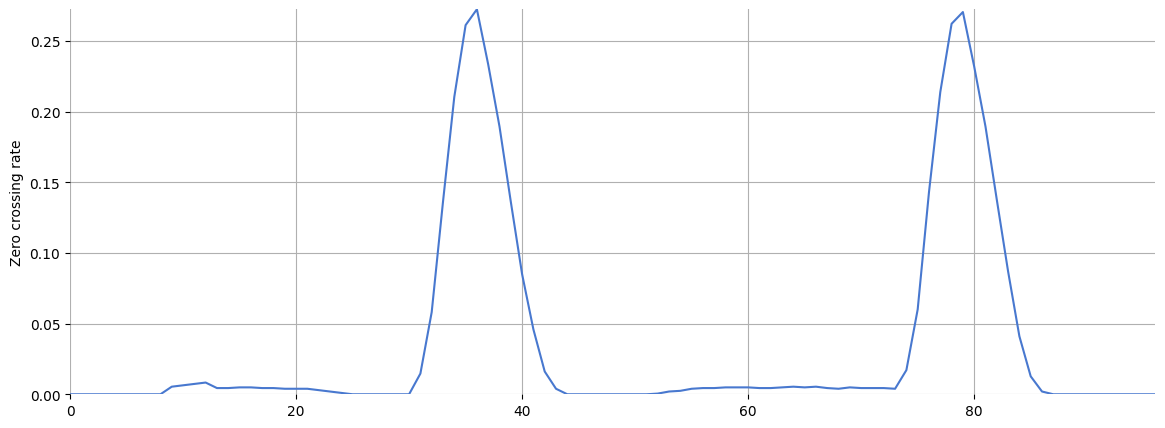

In [25]:
zcrs = librosa.feature.zero_crossing_rate(x + 0.0001)
plt.figure(figsize=(14, 5))
plt.plot(zcrs[0])
plt.ylabel("Zero crossing rate")

## Questions

Try for other audio files. Does the zero-crossing rate still return something useful in polyphonic mixtures?

In [26]:
mirdotcom.list_audio()

simple_piano.wav
latin_groove.mp3
clarinet_c6.wav
cowbell.wav
classic_rock_beat.mp3
oboe_c6.wav
sir_duke_trumpet_fast.mp3
sir_duke_trumpet_slow.mp3
jangle_pop.mp3
125_bounce.wav
brahms_hungarian_dance_5.mp3
58bpm.wav
conga_groove.wav
funk_groove.mp3
tone_440.wav
sir_duke_piano_fast.mp3
thx_original.mp3
simple_loop.wav
classic_rock_beat.wav
c_strum.wav
prelude_cmaj.wav
sir_duke_piano_slow.mp3
busta_rhymes_hits_for_days.mp3
